# Cross-Validation

Cross-validation is a model evaluation technique used to estimate how well a machine learning model will perform on unseen data.

Instead of evaluating a model using only one train-validation split, cross-validation creates multiple train-validation splits and evaluates the model several times.

The main goals of cross-validation are:

- Estimate model generalization performance
- Reduce dependence on a single train-validation split
- Compare different models fairly
- Tune hyperparameters
- Detect overfitting
- Make better use of limited training data

## Why Do We Need Cross-Validation?

Suppose we have a dataset containing 1,000 samples.

A simple approach is:

- 80% → Training data
- 20% → Validation data

We train the model on the training data and evaluate it on the validation data.

However, the result depends on the particular samples that happened to enter the validation set.

For example:

Split 1:

Training → Samples 1–800  
Validation → Samples 801–1000

Split 2:

Training → A different 800 samples  
Validation → Another 200 samples

The model may perform differently on these different validation sets.

Cross-validation solves this problem by performing multiple train-validation splits and combining their results.

Therefore:

Cross-validation gives us a more reliable estimate of model performance than relying on a single validation split.

## Basic Idea

In K-Fold Cross-Validation, the dataset is divided into K approximately equal-sized folds.

For example, with K = 5:

Fold 1
Fold 2
Fold 3
Fold 4
Fold 5

The model is trained and evaluated 5 times.

Iteration 1:

Training → Folds 2, 3, 4, 5
Validation → Fold 1

Iteration 2:

Training → Folds 1, 3, 4, 5
Validation → Fold 2

Iteration 3:

Training → Folds 1, 2, 4, 5
Validation → Fold 3

Iteration 4:

Training → Folds 1, 2, 3, 5
Validation → Fold 4

Iteration 5:

Training → Folds 1, 2, 3, 4
Validation → Fold 5

Every sample is used:

- For validation exactly once
- For training K - 1 times

## K-Fold Cross-Validation

K-Fold Cross-Validation divides the dataset into K folds.

For each fold:

1. Use that fold as the validation set.
2. Use all remaining folds as the training set.
3. Train the model.
4. Calculate the validation score.

After all K iterations, calculate the mean score.

If the validation scores are:

$$
s_1, s_2, s_3, \dots, s_K
$$

then the cross-validation score is:

$$
CV_{mean} =
\frac{1}{K}
\sum_{i=1}^{K} s_i
$$

We can also calculate the standard deviation:

$$
CV_{std} =
\sqrt{
\frac{1}{K}
\sum_{i=1}^{K}
(s_i - CV_{mean})^2
}
$$

The mean tells us the average performance.

The standard deviation tells us how much the model's performance changes across different folds.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import (
    train_test_split,
    KFold,
    StratifiedKFold,
    cross_val_score,
    cross_validate
)

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score

## Load a Dataset

We will use the Breast Cancer dataset.

This is a binary classification problem.

The target contains two classes:

- 0 → Malignant
- 1 → Benign

We will use cross-validation to evaluate classification models.

In [2]:
data = load_breast_cancer()

X = data.data
y = data.target

print("Feature shape:", X.shape)
print("Target shape:", y.shape)
print("Number of classes:", len(np.unique(y)))

Feature shape: (569, 30)
Target shape: (569,)
Number of classes: 2


In [3]:
print("Class distribution:")

unique, counts = np.unique(y, return_counts=True)

for class_value, count in zip(unique, counts):
    print(f"Class {class_value}: {count}")

Class distribution:
Class 0: 212
Class 1: 357


## Train-Test Split Before Cross-Validation

A very important practice is to keep a final test set separate.

We can divide the data into:

Training set → Used for model development and cross-validation

Test set → Used only once at the end for final evaluation.

For example:

    Full Dataset
    │
    ├── Training Set → Cross-Validation
    │
    └── Test Set → Final Evaluation

The test set should not participate in cross-validation.

This prevents information from the final evaluation set from influencing model selection.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])

Training samples: 455
Test samples: 114


# K-Fold Cross-Validation

K-Fold Cross-Validation is the standard form of cross-validation.

The training data is divided into K folds.

A common choice is:

$$
K = 5
$$

or

$$
K = 10
$$

A larger K means:

- More training data is used in each iteration
- More model training is required
- Computation increases

A smaller K means:

- Faster computation
- Each training iteration uses slightly less data

In [5]:
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

model = LogisticRegression(
    max_iter=5000
)

scores = cross_val_score(
    model,
    X_train,
    y_train,
    cv=kf,
    scoring="accuracy"
)

print("Fold scores:", scores)
print("Mean accuracy:", scores.mean())
print("Standard deviation:", scores.std())

Fold scores: [0.92307692 0.97802198 0.97802198 0.94505495 0.93406593]
Mean accuracy: 0.9516483516483516
Standard deviation: 0.02262775855161975


## Understanding the Result

Suppose the result is:

Fold 1 → 0.96  
Fold 2 → 0.95  
Fold 3 → 0.97  
Fold 4 → 0.94  
Fold 5 → 0.96

The mean accuracy represents the average performance:

$$
Accuracy_{mean}
=
\frac{
Accuracy_1 + Accuracy_2 + \dots + Accuracy_K
}{K}
$$

The standard deviation measures variation between folds.

A high standard deviation means the model behaves differently depending on which samples are used for validation.

A low standard deviation means the model's performance is more consistent across different folds.

## Why Do We Shuffle the Data?

K-Fold Cross-Validation can divide the dataset according to its original ordering.

If the dataset has some meaningful ordering, this can produce poor folds.

For example:

Samples 1–100 → Class A  
Samples 101–200 → Class B

Without shuffling, some folds may contain mostly one class.

Therefore, for many ordinary datasets, we use:

$$
shuffle = True
$$

and set a random state for reproducibility.

Example:

```python
KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

However, shuffling is NOT always appropriate.

For time-series data, we generally must preserve chronological order.



# Stratified K-Fold Cross-Validation

For classification problems, we usually prefer Stratified K-Fold.

Stratified K-Fold tries to preserve the class distribution in every fold.

Suppose the complete dataset contains:

Class 0 → 80%  
Class 1 → 20%

Stratified K-Fold attempts to keep approximately the same ratio in every fold:

Class 0 → approximately 80%  
Class 1 → approximately 20%

This is especially important when the classes are imbalanced.

In [6]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    model,
    X_train,
    y_train,
    cv=skf,
    scoring="accuracy"
)

print("Fold scores:", scores)
print("Mean accuracy:", scores.mean())
print("Standard deviation:", scores.std())

Fold scores: [0.96703297 0.92307692 0.94505495 0.95604396 0.92307692]
Mean accuracy: 0.9428571428571428
Standard deviation: 0.017582417582417565


## K-Fold vs Stratified K-Fold

### K-Fold

K-Fold divides samples into folds without explicitly preserving class proportions.

It is commonly used for:

- Regression
- Unstructured datasets
- Problems where class distribution is not relevant

### Stratified K-Fold

Stratified K-Fold preserves approximately the same class distribution in each fold.

It is commonly used for:

- Binary classification
- Multiclass classification
- Imbalanced classification

### Practical Rule

For classification:

Use StratifiedKFold unless there is a specific reason not to.

For regression:

Use KFold.

For time-series:

Use TimeSeriesSplit.

# Cross-Validation and Data Preprocessing

A common mistake is to preprocess the entire dataset before cross-validation.

For example:

```python
scaler.fit_transform(X_train)

before performing cross-validation can cause data leakage if the transformation learns information from samples that later become validation samples.

The correct approach is to perform preprocessing separately inside each training fold.

A Pipeline handles this correctly.

The process becomes:

    Training Fold
    ↓
    Fit Scaler
    ↓
    Transform Training Fold
    ↓
    Train Model
    ↓
    Transform Validation Fold using the same scaler
    ↓
    Evaluate Model

This prevents validation information from leaking into the training process.

In [7]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=5000))
])

scores = cross_val_score(
    pipeline,
    X_train,
    y_train,
    cv=skf,
    scoring="accuracy"
)

print("Fold scores:", scores)
print("Mean accuracy:", scores.mean())
print("Standard deviation:", scores.std())

Fold scores: [0.96703297 0.98901099 0.97802198 0.98901099 0.96703297]
Mean accuracy: 0.9780219780219781
Standard deviation: 0.009828870230768321


## Why Pipeline Is Important

Suppose we calculate the mean and standard deviation of every feature using the entire dataset.

Then we perform cross-validation.

The validation fold has already influenced the preprocessing parameters.

This is a form of data leakage.

With a Pipeline:

$$
Training\ Fold
\rightarrow
Fit\ Preprocessing
\rightarrow
Transform
\rightarrow
Train\ Model
$$

and:

$$
Validation\ Fold
\rightarrow
Transform\ Only
\rightarrow
Evaluate
$$

The preprocessing parameters are learned only from the training portion of each fold.

Therefore, Pipeline is one of the safest ways to combine preprocessing and cross-validation.

# Multiple Evaluation Metrics

Accuracy is not always enough.

For classification problems, we may want:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

Cross-validation can calculate multiple metrics simultaneously.

In [8]:
scoring = [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc"
]

cv_results = cross_validate(
    pipeline,
    X_train,
    y_train,
    cv=skf,
    scoring=scoring,
    return_train_score=True
)

for metric in scoring:
    scores = cv_results[f"test_{metric}"]
    
    print(f"{metric}:")
    print("  Mean:", scores.mean())
    print("  Std :", scores.std())
    print()

accuracy:
  Mean: 0.9780219780219781
  Std : 0.009828870230768321

precision:
  Mean: 0.9794715236366779
  Std : 0.01622860446208697

recall:
  Mean: 0.9859649122807017
  Std : 0.013128622409733132

f1:
  Mean: 0.9825442464894886
  Std : 0.007752336477690741

roc_auc:
  Mean: 0.9958720330237357
  Std : 0.004960006126191094



## Training Score vs Validation Score

Cross-validation can also return training scores.

This is useful for detecting overfitting.

Suppose:

Training accuracy → 99%

Validation accuracy → 85%

There is a large gap.

This may indicate overfitting.

If:

Training accuracy → 90%

Validation accuracy → 89%

The model is more consistent between training and validation data.

Therefore, comparing training and validation performance can provide useful information about model behavior.

In [9]:
train_scores = cv_results["train_accuracy"]
validation_scores = cv_results["test_accuracy"]

print("Training accuracy:")
print(train_scores)

print("\nValidation accuracy:")
print(validation_scores)

print("\nMean training accuracy:", train_scores.mean())
print("Mean validation accuracy:", validation_scores.mean())

Training accuracy:
[0.98901099 0.98901099 0.98901099 0.98901099 0.98901099]

Validation accuracy:
[0.96703297 0.98901099 0.97802198 0.98901099 0.96703297]

Mean training accuracy: 0.989010989010989
Mean validation accuracy: 0.9780219780219781


# Cross-Validation for Model Comparison

Cross-validation is useful for comparing different machine learning models.

For example, we can compare:

- Logistic Regression
- Decision Tree
- Random Forest

We should use the same folds and evaluation metric when comparing models.

This makes the comparison more consistent.

In [10]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=5000))
    ]),
    
    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    )
}

results = {}

for name, model in models.items():
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=skf,
        scoring="accuracy"
    )
    
    results[name] = {
        "Mean Accuracy": scores.mean(),
        "Std Accuracy": scores.std()
    }

results_df = pd.DataFrame(results).T

results_df

,Mean Accuracy,Std Accuracy
Logistic Regression,0.978022,0.009829
Decision Tree,0.916484,0.017855
Random Forest,0.962637,0.017855


## Interpreting Model Comparison

When comparing models, consider both:

### Mean Performance

Higher mean validation performance is generally better.

### Stability

Lower standard deviation generally means more consistent performance across folds.

For example:

Model A:

Mean = 0.95  
Std = 0.01

Model B:

Mean = 0.96  
Std = 0.08

Model B has a slightly higher average score but much higher variability.

Therefore, model selection should not blindly depend on the highest mean score.

We should consider:

- Performance
- Stability
- Computational cost
- Interpretability
- Complexity
- Business requirements

# Choosing the Number of Folds

The value of K controls the number of cross-validation folds.

Common choices:

$$
K = 5
$$

or:

$$
K = 10
$$

### Small K

Example:

$$
K = 5
$$

Advantages:

- Faster
- Lower computational cost
- Usually provides a good estimate

### Large K

Example:

$$
K = 10
$$

Advantages:

- More training data per iteration
- Can provide a detailed estimate

Disadvantages:

- More computation
- More model training
- Can have higher variance in some situations

In practice, 5-fold or 10-fold cross-validation is usually sufficient.

# Leave-One-Out Cross-Validation

Leave-One-Out Cross-Validation (LOOCV) is an extreme form of K-Fold Cross-Validation.

If there are N samples:

$$
K = N
$$

Each iteration uses:

Training → N - 1 samples

Validation → 1 sample

This process is repeated N times.

Therefore, the model is trained N times.

### Advantages

- Almost all data is used for training in every iteration
- Useful for very small datasets

### Disadvantages

- Computationally expensive
- Can have high variance
- Usually unnecessary for large datasets

LOOCV is therefore mainly useful for small datasets.

# Time-Series Cross-Validation

Ordinary K-Fold Cross-Validation should not be blindly used for time-series data.

Suppose we are predicting stock prices.

We cannot train on future data and validate on past data.

That would introduce future information into the training process.

Instead, we preserve chronological order.

Example:

Fold 1:

Training → January  
Validation → February

Fold 2:

Training → January + February  
Validation → March

Fold 3:

Training → January + February + March  
Validation → April

This approach is commonly implemented using TimeSeriesSplit.

The main principle is:

Past → Training

Future → Validation

In [11]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

print(tscv)

TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None)


# Cross-Validation for Hyperparameter Tuning

Cross-validation is frequently used during hyperparameter tuning.

Suppose a Decision Tree has a hyperparameter:

$$
max\_depth
$$

We may want to determine whether:

$$
max\_depth = 2, 3, 4, 5, 6
$$

produces the best validation performance.

For every hyperparameter value, cross-validation can calculate an average score.

The hyperparameter with the best cross-validation performance can then be selected.

In [12]:
from sklearn.model_selection import GridSearchCV

pipeline_tree = Pipeline([
    ("model", DecisionTreeClassifier(random_state=42))
])

param_grid = {
    "model__max_depth": [2, 3, 4, 5, 6, 8, 10]
}

grid_search = GridSearchCV(
    pipeline_tree,
    param_grid=param_grid,
    cv=skf,
    scoring="accuracy",
    return_train_score=True
)

grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)

print("\nBest CV score:")
print(grid_search.best_score_)

Best parameters:
{'model__max_depth': 2}

Best CV score:
0.9318681318681319


In [13]:
grid_results = pd.DataFrame(grid_search.cv_results_)

grid_results[
    [
        "param_model__max_depth",
        "mean_train_score",
        "mean_test_score",
        "std_test_score"
    ]
]

,param_model__max_depth,mean_train_score,mean_test_score,std_test_score
0,2,0.961538,0.931868,0.018906
1,3,0.979121,0.925275,0.008223
2,4,0.987912,0.929670,0.014906
3,5,0.992308,0.923077,0.012038
4,6,0.997253,0.925275,0.012815
5,8,0.999451,0.923077,0.012038
6,10,1.000000,0.916484,0.017855


## Visualizing Hyperparameter Performance

We can visualize how the validation score changes with the hyperparameter.

This helps us understand:

- Underfitting
- Good model complexity
- Overfitting

For example:

Very small max_depth
→ Model may underfit

Moderate max_depth
→ Good generalization

Very large max_depth
→ Model may overfit

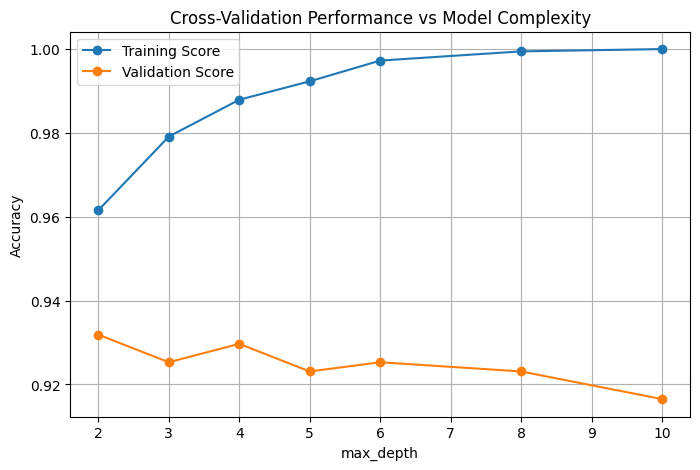

In [14]:
depths = grid_results["param_model__max_depth"].astype(int)
train_scores = grid_results["mean_train_score"]
validation_scores = grid_results["mean_test_score"]

plt.figure(figsize=(8, 5))

plt.plot(
    depths,
    train_scores,
    marker="o",
    label="Training Score"
)

plt.plot(
    depths,
    validation_scores,
    marker="o",
    label="Validation Score"
)

plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Cross-Validation Performance vs Model Complexity")

plt.legend()
plt.grid(True)

plt.show()

# Cross-Validation vs Train-Test Split

Both techniques are useful, but they serve different purposes.

### Train-Test Split

Dataset:

Training → 80%

Testing → 20%

Advantages:

- Simple
- Fast
- Easy to understand

Disadvantages:

- Performance depends on one split
- Can produce an unstable estimate

### Cross-Validation

Training data is divided into multiple folds.

Advantages:

- More reliable estimate
- Uses multiple validation sets
- Useful for model comparison
- Useful for hyperparameter tuning

Disadvantages:

- More computationally expensive
- More complex

### Best Practical Approach

A strong workflow is:

Full Dataset
│
├── Training Set
│   └── Cross-Validation
│       ├── Model Selection
│       └── Hyperparameter Tuning
│
└── Test Set
    └── Final Evaluation

# Data Leakage

Data leakage occurs when information from outside the training data is unintentionally used during model training.

This can make validation performance look better than the model's true performance.

Common examples:

- Scaling before cross-validation
- Feature selection before cross-validation
- Imputation using the complete dataset
- Using future information in time-series prediction
- Oversampling before cross-validation

The general rule is:

Any operation that learns information from the data should be performed separately inside each training fold.

A Pipeline is the safest way to achieve this for preprocessing steps.

## Feature Selection and Cross-Validation

Feature selection can also cause leakage.

Incorrect:

1. Select features using the complete training dataset.
2. Perform cross-validation on the selected features.

The validation folds have influenced which features were selected.

Correct:

For every fold:

Training Fold
↓
Feature Selection
↓
Model Training
↓
Validation Fold
↓
Evaluation

Feature selection should therefore be included inside a Pipeline when appropriate.

# Cross-Validation with Imbalanced Data

Suppose a classification dataset contains:

Class 0 → 95%

Class 1 → 5%

A model that predicts Class 0 for every sample could achieve:

$$
Accuracy = 95\%
$$

But the model is not useful for detecting Class 1.

For imbalanced classification:

- Prefer StratifiedKFold
- Consider precision
- Consider recall
- Consider F1-score
- Consider ROC-AUC
- Sometimes consider PR-AUC

Accuracy alone can be misleading.

# Repeated Cross-Validation

A single K-Fold split produces one particular arrangement of folds.

Repeated cross-validation performs K-Fold cross-validation multiple times using different fold arrangements.

For example:

5-Fold × 3 Repeats

means:

5 folds are created
↓
The process is repeated 3 times
↓
15 validation evaluations are performed

This can provide a more stable estimate of model performance.

In scikit-learn, RepeatedKFold and RepeatedStratifiedKFold can be used.

In [15]:
from sklearn.model_selection import RepeatedStratifiedKFold

repeated_cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=3,
    random_state=42
)

scores = cross_val_score(
    pipeline,
    X_train,
    y_train,
    cv=repeated_cv,
    scoring="accuracy"
)

print("Number of scores:", len(scores))
print("Mean accuracy:", scores.mean())
print("Standard deviation:", scores.std())

Number of scores: 15
Mean accuracy: 0.972893772893773
Standard deviation: 0.009719047004704473


# Final Model Evaluation

Cross-validation is used during model development.

After selecting the model and hyperparameters, we train the final model using the complete training dataset.

Then we evaluate it once on the untouched test set.

The process is:

Training Data
↓
Cross-Validation
↓
Model + Hyperparameter Selection
↓
Train Final Model on Entire Training Set
↓
Evaluate on Test Set

In [16]:
best_model = grid_search.best_estimator_

best_model.fit(
    X_train,
    y_train
)

test_predictions = best_model.predict(X_test)

test_accuracy = accuracy_score(
    y_test,
    test_predictions
)

print("Final Test Accuracy:", test_accuracy)

Final Test Accuracy: 0.8947368421052632


# Complete Cross-Validation Workflow

A practical machine learning workflow looks like this:

## Step 1 — Split the data

Separate the final test set.

$$
Dataset
\rightarrow
Training + Test
$$

## Step 2 — Select a cross-validation strategy

For ordinary classification:

$$
StratifiedKFold
$$

For regression:

$$
KFold
$$

For time series:

$$
TimeSeriesSplit
$$

## Step 3 — Build a Pipeline

Include preprocessing and the model.

$$
Preprocessing
\rightarrow
Model
$$

## Step 4 — Perform Cross-Validation

Estimate the model's generalization performance.

## Step 5 — Tune Hyperparameters

Use GridSearchCV or RandomizedSearchCV.

## Step 6 — Select the Best Model

Choose the model based on the appropriate validation metric.

## Step 7 — Train the Final Model

Train the selected model on the complete training set.

## Step 8 — Evaluate Once on the Test Set

Use the untouched test set to estimate final generalization performance.

# Important Cross-Validation Rules

### Rule 1

Do not use the test set during model selection.

### Rule 2

For classification, generally prefer StratifiedKFold.

### Rule 3

For time-series data, preserve temporal order.

### Rule 4

Put preprocessing inside a Pipeline.

### Rule 5

Do not select features using the complete dataset before cross-validation.

### Rule 6

Do not perform oversampling before cross-validation.

Instead, oversampling should happen inside each training fold.

### Rule 7

Choose evaluation metrics according to the problem.

Do not automatically use accuracy.

### Rule 8

Look at both mean and standard deviation of cross-validation scores.

### Rule 9

Cross-validation estimates performance; it does not magically eliminate overfitting.

### Rule 10

Keep a final untouched test set when you need an unbiased final evaluation.

# Disadvantages of Cross-Validation

## Disadvantages

### 1. Computationally expensive

If:

$$
K = 10
$$

the model may need to be trained approximately 10 times.

With hyperparameter tuning, the number of model fits can become very large.

### 2. More complex

Cross-validation requires more careful implementation than a simple train-test split.

### 3. Can still be affected by poor data splitting

The wrong cross-validation strategy can produce misleading results.

### 4. Not automatically suitable for every dataset

Time-series data, grouped data, and other structured datasets may require specialized cross-validation strategies.

### 5. Can still overfit the validation process

If we try enough hyperparameters and repeatedly optimize against cross-validation results, we can eventually overfit our model-selection process.

# Important Types of Cross-Validation

| Method | Typical Use |
|---|---|
| K-Fold | General datasets |
| Stratified K-Fold | Classification |
| Repeated K-Fold | More stable estimates |
| Repeated Stratified K-Fold | Classification |
| Leave-One-Out | Very small datasets |
| TimeSeriesSplit | Time-series data |
| GroupKFold | Grouped observations |
| StratifiedGroupKFold | Grouped classification |

The most important idea is not memorizing every method.

The important idea is choosing a splitting strategy that matches the structure of your data.

# cross_val_score vs cross_validate

### cross_val_score

Use when you mainly need one evaluation metric.

Example:

```python
cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

cross_validate

Use when you need multiple metrics or additional information such as training scores and fit times.

Example:

```python
cross_validate(
    model,
    X,
    y,
    cv=5,
    scoring=["accuracy", "f1", "roc_auc"],
    return_train_score=True
)|

Therefore:

cross_val_score → simple evaluation

cross_validate → detailed evaluation


---


# Summary

Cross-validation is a technique for estimating how well a machine learning model will generalize to unseen data.

The most important method is K-Fold Cross-Validation.

In K-Fold Cross-Validation:

$$
Dataset \rightarrow K\ Folds
$$

The model is trained K times.

Each fold is used once as validation data.

The final score is usually summarized using:

$$
Mean\ Score
$$

and:

$$
Standard\ Deviation
$$

For classification, StratifiedKFold is generally preferred because it preserves class proportions.

For time-series data, chronological splitting should be used.

Preprocessing should be performed inside a Pipeline to prevent data leakage.

Cross-validation is useful for:

- Model evaluation
- Model comparison
- Hyperparameter tuning
- Detecting overfitting
- Measuring performance stability

A strong practical workflow is:

$$
Dataset
\rightarrow
Train/Test\ Split
$$

$$
Training\ Set
\rightarrow
Cross\ Validation
\rightarrow
Model\ Selection
\rightarrow
Hyperparameter\ Tuning
$$

$$
Best\ Model
\rightarrow
Train\ on\ Complete\ Training\ Set
$$

$$
Final\ Evaluation
\rightarrow
Untouched\ Test\ Set
$$

The key principle is:

**Use cross-validation for model development, and keep the final test set untouched until the end.**